In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import zipfile
import seaborn as sns
import numpy as np

In [3]:
zip_file_name="im.db.zip"
with zipfile.ZipFile(zip_file_name,'r')as zip_ref:
    zip_ref.extractall()

In [2]:
con=sqlite3.connect("im.db")

In [6]:
cur=con.cursor()

In [7]:
cur.execute('''SELECT name FROM sqlite_master WHERE type='table' ''');
cur.fetchall()


[('movie_basics',),
 ('directors',),
 ('known_for',),
 ('movie_akas',),
 ('movie_ratings',),
 ('persons',),
 ('principals',),
 ('writers',)]

In [7]:
cur.execute('''SELECT * FROM movie_akas''');
cur.fetchall()

[('tt0369610', 10, 'Джурасик свят', 'BG', 'bg', None, None, 0.0),
 ('tt0369610', 11, 'Jurashikku warudo', 'JP', None, 'imdbDisplay', None, 0.0),
 ('tt0369610',
  12,
  'Jurassic World: O Mundo dos Dinossauros',
  'BR',
  None,
  'imdbDisplay',
  None,
  0.0),
 ('tt0369610',
  13,
  'O Mundo dos Dinossauros',
  'BR',
  None,
  None,
  'short title',
  0.0),
 ('tt0369610', 14, 'Jurassic World', 'FR', None, 'imdbDisplay', None, 0.0),
 ('tt0369610', 15, 'Jurassic World', 'GR', None, 'imdbDisplay', None, 0.0),
 ('tt0369610', 16, 'Jurassic World', 'IT', None, 'imdbDisplay', None, 0.0),
 ('tt0369610', 17, 'Jurski svijet', 'HR', None, 'imdbDisplay', None, 0.0),
 ('tt0369610', 18, "Olam ha'Yura", 'IL', 'he', 'imdbDisplay', None, 0.0),
 ('tt0369610',
  19,
  'Jurassic World: Mundo Jurásico',
  'MX',
  None,
  'imdbDisplay',
  None,
  0.0),
 ('tt0369610',
  1,
  'Jurassic World: Sauruste maailm',
  'EE',
  None,
  'imdbDisplay',
  None,
  0.0),
 ('tt0369610', 20, 'Jurassic World', 'SE', None, 'im

In [8]:
cur.execute('''SELECT * FROM movie_ratings''');
cur.fetchall()

[('tt10356526', 8.3, 31),
 ('tt10384606', 8.9, 559),
 ('tt1042974', 6.4, 20),
 ('tt1043726', 4.2, 50352),
 ('tt1060240', 6.5, 21),
 ('tt1069246', 6.2, 326),
 ('tt1094666', 7.0, 1613),
 ('tt1130982', 6.4, 571),
 ('tt1156528', 7.2, 265),
 ('tt1161457', 4.2, 148),
 ('tt1171222', 5.1, 8296),
 ('tt1174693', 5.8, 2381),
 ('tt1181840', 7.0, 5494),
 ('tt1193623', 8.0, 5),
 ('tt1199588', 5.5, 74),
 ('tt1204784', 5.8, 6),
 ('tt1210166', 7.6, 326657),
 ('tt1212419', 6.5, 87288),
 ('tt1220911', 5.0, 941),
 ('tt1229238', 7.4, 428142),
 ('tt1232829', 7.2, 477771),
 ('tt1235548', 6.6, 2725),
 ('tt1243974', 5.4, 54646),
 ('tt1250861', 6.2, 416),
 ('tt1258812', 4.0, 21),
 ('tt1261945', 4.4, 69199),
 ('tt1266037', 7.0, 1413),
 ('tt1270291', 5.8, 5728),
 ('tt1270761', 5.6, 44490),
 ('tt1272886', 6.1, 6688),
 ('tt1274297', 5.4, 381),
 ('tt1283887', 5.4, 2527),
 ('tt1285219', 3.4, 387),
 ('tt1287879', 7.7, 76),
 ('tt1290476', 7.2, 6),
 ('tt1294141', 4.5, 113),
 ('tt1320239', 6.2, 18431),
 ('tt1322312', 6.3

In [9]:
df_ratings=pd.read_sql_query('''SELECT * FROM movie_ratings''',con)
print(df_ratings)

         movie_id  averagerating  numvotes
0      tt10356526            8.3        31
1      tt10384606            8.9       559
2       tt1042974            6.4        20
3       tt1043726            4.2     50352
4       tt1060240            6.5        21
...           ...            ...       ...
73851   tt9805820            8.1        25
73852   tt9844256            7.5        24
73853   tt9851050            4.7        14
73854   tt9886934            7.0         5
73855   tt9894098            6.3       128

[73856 rows x 3 columns]


In [18]:
df_aka=pd.read_sql_query('''SELECT * FROM movie_akas''',con)
print(df_aka)

         movie_id  ordering                                    title region  \
0       tt0369610        10                            Джурасик свят     BG   
1       tt0369610        11                        Jurashikku warudo     JP   
2       tt0369610        12  Jurassic World: O Mundo dos Dinossauros     BR   
3       tt0369610        13                  O Mundo dos Dinossauros     BR   
4       tt0369610        14                           Jurassic World     FR   
...           ...       ...                                      ...    ...   
331698  tt9827784         2                       Sayonara kuchibiru   None   
331699  tt9827784         3                            Farewell Song    XWW   
331700  tt9880178         1                              La atención   None   
331701  tt9880178         2                              La atención     ES   
331702  tt9880178         3                            The Attention    XWW   

       language        types   attributes  is_origi

In [10]:
query = """
SELECT 
    b.primary_title, 
    b.genres, 
    b.runtime_minutes, 
    r.averagerating, 
    r.numvotes
FROM movie_basics AS b
JOIN movie_ratings AS r ON b.movie_id = r.movie_id
WHERE r.numvotes > 1000  -- Filter for movies with enough data to be 'reliable'
"""

df = pd.read_sql(query, con)
df.head()


,primary_title,genres,runtime_minutes,averagerating,numvotes
0,The Legend of Hercules,"Action,Adventure,Fantasy",99.0,4.2,50352
1,The Hammer,"Biography,Drama,Sport",108.0,7.0,1613
2,Baggage Claim,Comedy,96.0,5.1,8296
3,The Four-Faced Liar,"Comedy,Drama,Romance",87.0,5.8,2381
4,Jack and the Cuckoo-Clock Heart,"Adventure,Animation,Drama",94.0,7.0,5494


In [5]:
querry= '''
SELECT mb.primary_title, mb.genres, mr.averagerating, mr.numvotes
FROM movie_basics mb
JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
WHERE mr.numvotes >= 1000
ORDER BY mr.averagerating DESC
LIMIT 20
'''
df = pd.read_sql(querry,con)
df

,primary_title,genres,averagerating,numvotes
0,Once Upon a Time ... in Hollywood,"Comedy,Drama",9.7,5600
1,Ekvtime: Man of God,"Biography,Drama,History",9.6,2604
2,I Want to Live,"Adventure,Biography,Documentary",9.6,1339
3,Aloko Udapadi,"Drama,History",9.5,6509
4,Peranbu,Drama,9.4,9629
5,The Mountain II,"Action,Drama,War",9.3,100568
6,Aynabaji,"Crime,Mystery,Thriller",9.3,18470
7,Wheels,Drama,9.3,17308
8,Truth and Justice,Drama,9.3,1220
9,Dominion,Documentary,9.2,1096


In [11]:
df['genres'] = df['genres'].str.split(',')

genre_df = df.explode('genres')

top_genres = genre_df.groupby('genres')['averagerating'].mean().sort_values(ascending=False)
print(top_genres.head(10))

genres
News           7.722222
Documentary    7.267973
Biography      6.957347
Sport          6.932653
History        6.893264
Music          6.750177
War            6.720859
Animation      6.682713
Musical        6.537143
Drama          6.485488
Name: averagerating, dtype: float64


In [27]:
#removing null values

In [12]:
df.replace('\\N', np.nan, inplace=True)

In [13]:
df.dropna(subset=['averagerating', 'genres'], inplace=True)
print(df.isna().sum())

primary_title      0
genres             0
runtime_minutes    8
averagerating      0
numvotes           0
dtype: int64


In [1]:
#query to join movie details with ratings

In [14]:
genre_query = """
SELECT 
    m.genres, 
    AVG(r.averagerating) as avg_rating, 
    COUNT(m.movie_id) as movie_count
FROM movie_basics AS m
JOIN movie_ratings AS r ON m.movie_id = r.movie_id
GROUP BY m.genres
HAVING movie_count > 50 
ORDER BY avg_rating DESC
LIMIT 10;
"""

df_genre = pd.read_sql(genre_query, con)
print (df_genre)


                            genres  avg_rating  movie_count
0                            Music    7.615341          176
1            Adventure,Documentary    7.567692          130
2      Biography,Documentary,Music    7.566250          240
3       Documentary,Family,History    7.554902           51
4        Documentary,History,Music    7.546341           82
5     Biography,Documentary,Family    7.536364          132
6          Documentary,History,War    7.532584           89
7                Documentary,Sport    7.500000          318
8      Biography,Documentary,Drama    7.498674          377
9  Adventure,Biography,Documentary    7.492982          114


In [12]:
#visual of thr above

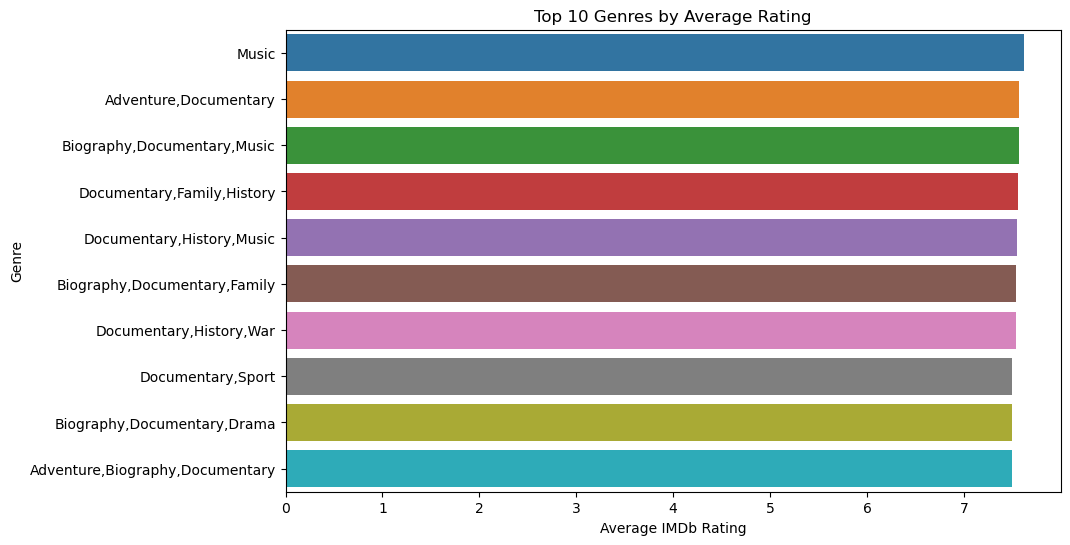

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_genre, x='avg_rating', y='genres')
plt.title('Top 10 Genres by Average Rating')
plt.xlabel('Average IMDb Rating')
plt.ylabel('Genre')
plt.show()

In [ ]:
#movie category
#recommend the new studio to consider high quality unscripted content(documentaries and biographies) since they consistently yield higher audience satisfaction scores in comparison to action and comedy titles.
#music is also not a bad option

In [17]:
#do longer movies lead to higher audience ratings

In [10]:
runtime_query = """
SELECT runtime_minutes, averagerating
FROM movie_basics
JOIN movie_ratings USING (movie_id)
WHERE runtime_minutes IS NOT NULL AND runtime_minutes BETWEEN 60 AND 200
LIMIT 20;
"""

df_runtime = pd.read_sql(runtime_query, con)
print(df_runtime)

    runtime_minutes  averagerating
0             175.0            7.0
1             114.0            7.2
2             122.0            6.9
3              80.0            6.5
4              83.0            8.1
5             136.0            6.8
6             100.0            4.6
7             180.0            7.6
8              89.0            6.9
9              60.0            7.5
10            160.0            7.8
11            104.0            4.0
12            120.0            8.8
13            110.0            4.0
14             91.0            1.9
15            134.0            6.6
16             75.0            5.9
17             97.0            7.4
18            100.0            3.9
19             86.0            6.6


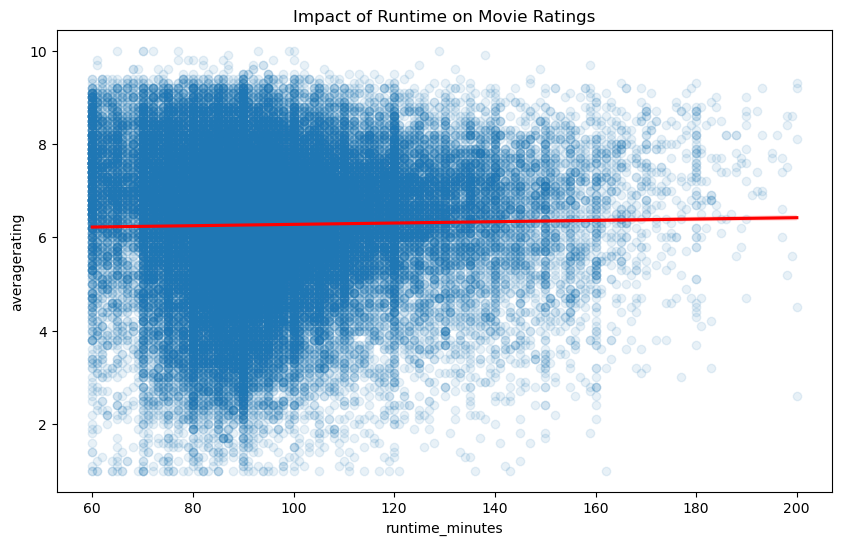

In [22]:
#visualization of the above
plt.figure(figsize=(10, 6))
sns.regplot(data=df_runtime, x='runtime_minutes', y='averagerating', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Impact of Runtime on Movie Ratings')
plt.show()

In [23]:
#directors to work with based on their movie ratings

In [17]:
director_query = """
SELECT 
    p.primary_name as director_name,
    AVG(r.averagerating) as avg_rating
FROM persons p
JOIN directors d ON p.person_id = d.person_id
JOIN movie_ratings r ON d.movie_id = r.movie_id
GROUP BY director_name
HAVING COUNT(d.movie_id) > 3
ORDER BY avg_rating DESC
LIMIT 10;
"""

df_directors = pd.read_sql(director_query, con)
print("Top Recommended Directors:\n", df_directors)

Top Recommended Directors:
        director_name  avg_rating
0     D. Todd Deeken    9.500000
1      David Beriain    9.300000
2             Fan Li    9.214286
3        Damir Radic    9.200000
4         Zach Logan    9.200000
5    Nathan D. Myers    9.200000
6  Marjolein Hermans    9.200000
7         Kris Flink    9.200000
8    Kara Kwiecinski    9.200000
9        Greg Werner    9.200000


In [ ]:
#these are the directors who have more than three productions with positive reviewsand significantly higher ratings
#the studio should consider them for their debut

In [18]:

positive_directors = df_directors[df_directors['avg_rating'] >= 7.0]

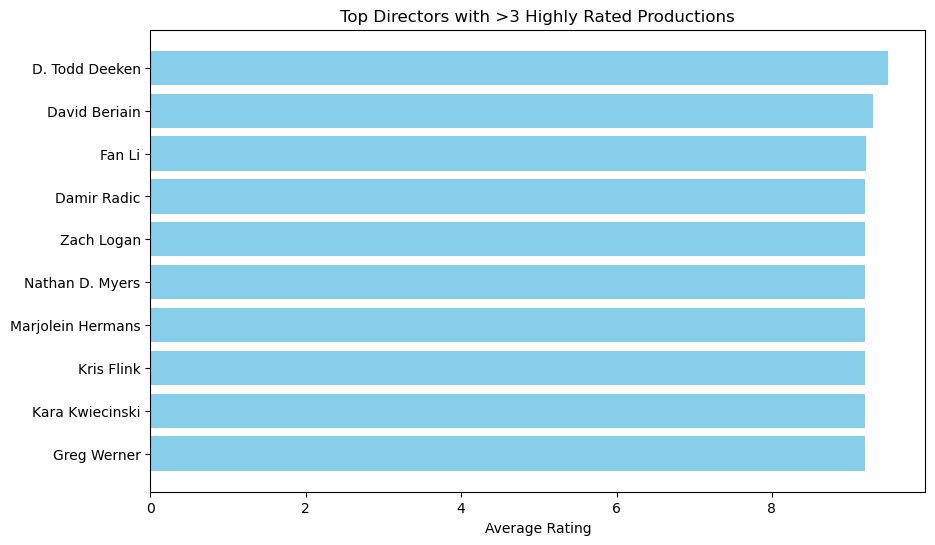

In [19]:
plt.figure(figsize=(10,6))
plt.barh(df_directors['director_name'], df_directors['avg_rating'], color='skyblue')
plt.xlabel('Average Rating')
plt.title('Top Directors with >3 Highly Rated Productions')
plt.gca().invert_yaxis() # Highest rating at the top
plt.show()

In [12]:
query_writers = '''
SELECT p.primary_name, mb.primary_title, mr.averagerating, mr.numvotes
FROM writers w
JOIN persons p ON w.person_id = p.person_id
JOIN movie_basics mb ON w.movie_id = mb.movie_id
JOIN movie_ratings mr ON w.movie_id = mr.movie_id
WHERE mr.numvotes >= 1000
ORDER BY mr.averagerating DESC
LIMIT 20
'''

df_writers = pd.read_sql(query_writers, con)
df_writers

,primary_name,primary_title,averagerating,numvotes
0,Quentin Tarantino,Once Upon a Time ... in Hollywood,9.7,5600
1,Nikoloz Khomasuridze,Ekvtime: Man of God,9.6,2604
2,Lasha Kankava,Ekvtime: Man of God,9.6,2604
3,Karzan Kardozi,I Want to Live,9.6,1339
4,Saman Weeraman,Aloko Udapadi,9.5,6509
5,Saman Weeraman,Aloko Udapadi,9.5,6509
6,Ram,Peranbu,9.4,9629
7,Ram,Peranbu,9.4,9629
8,Ram,Peranbu,9.4,9629
9,Anjana Krishnakumar,Peranbu,9.4,9629
